In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Best test loss epoch
def find_best_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    best_epoch = df.loc[df[rmse_column].idxmin()]
    return int(best_epoch['Epoch']), best_epoch[rmse_column]

# Last epoch
def find_last_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    last_epoch = df.iloc[-1]
    return int(last_epoch['Epoch']), last_epoch[rmse_column]

def plot_comparative_lr_blstm_log_file(metrics_csv_1, metrics_csv_2, coords, metrics_img, model):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 14

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1[f'Train {model} RMSE'], label='ADAM, LR=1e-4', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2[f'Train {model} RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1.set_title('Training', loc='right', fontsize=fontsize)

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1[f'Test {model} RMSE'], label='ADAM, LR=1e-4', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2[f'Test {model} RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2.set_title('Testing', loc='right', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, f'Test {model} RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, f'Test {model} RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"ADAM, LR=1e-4: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(coords['ADAM, LR:1e-4']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(coords['ADAM, LR:1e-5']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

def plot_comparative_lr_log_file(metrics_csv_1, metrics_csv_2, coords, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 14

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='ADAM, LR=1e-4', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1.set_title('Training', loc='right', fontsize=fontsize)

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='ADAM, LR=1e-4', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ADAM, LR=1e-5', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2.set_title('Testing', loc='right', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"ADAM, LR=1e-4: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ADAM, LR=1e-5: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(coords['ADAM, LR:1e-4']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(coords['ADAM, LR:1e-5']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

---
### BERT-BLSTM Initialized w/ BERT_MLM_ESM_INIT

Binding:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 407, rmse 1.0088
ADAM, LR=1e-5: epoch 999, rmse 1.1019

Expression:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 939, rmse 0.5604
ADAM, LR=1e-5: epoch 909, rmse 0.5908


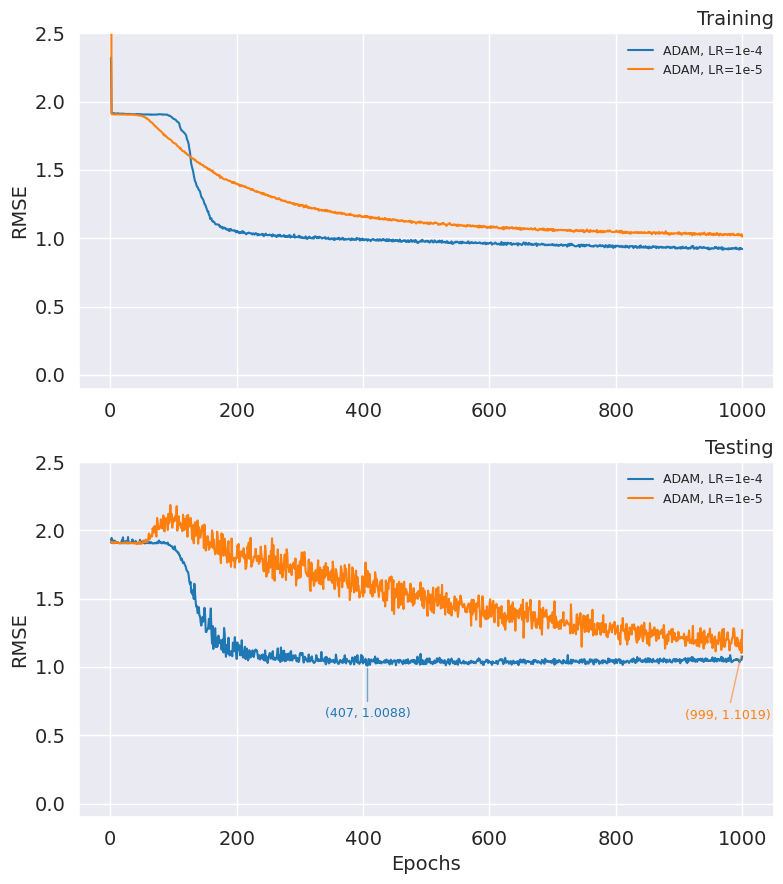

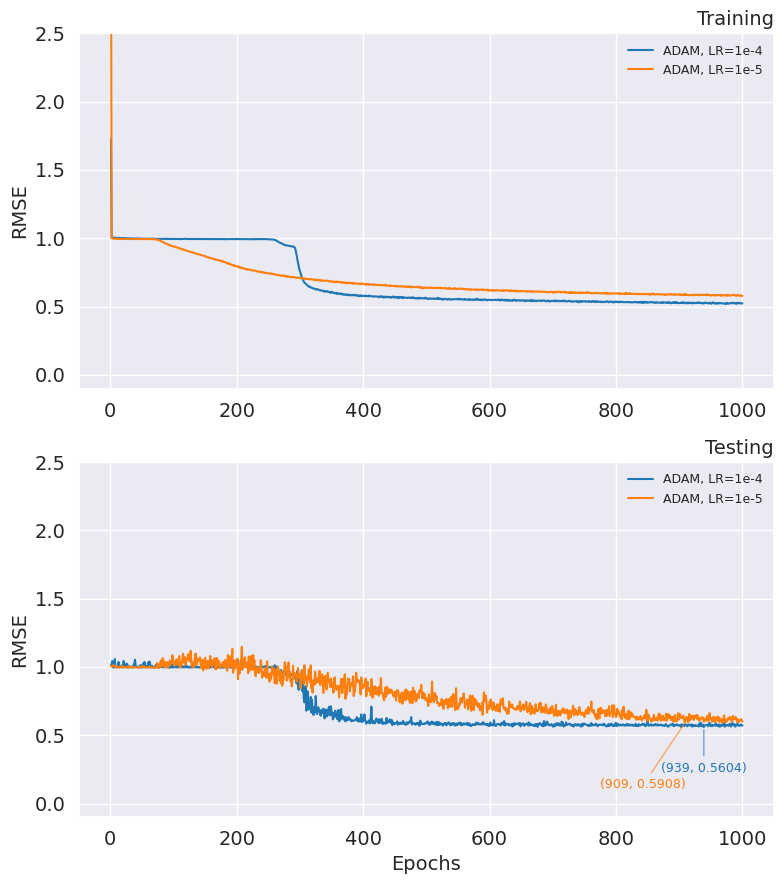

In [23]:
b_adam_lr_1e_neg_4 = "../../results/run_results/bert_blstm/adam.lr1e-04.bert_blstm-DMS_OLD-binding-2024-12-07_02-56/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/bert_blstm/adam.lr1e-05.bert_blstm-DMS_OLD-binding-2024-12-05_18-11/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_blstm.binding"
b_coords = {
    "ADAM, LR:1e-4": (0,-30),
    "ADAM, LR:1e-5": (-10,-40)
}
print("Binding:")
plot_comparative_lr_blstm_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf", "BLSTM")

e_adam_lr_1e_neg_4 = "../../results/run_results/bert_blstm/adam.lr1e-04.bert_blstm-DMS_OLD-expression-2024-12-07_02-58/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/bert_blstm/adam.lr1e-05.bert_blstm-DMS_OLD-expression-2024-12-05_18-12/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_blstm.expression"
e_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (-30,-40)
}
print("\nExpression:")
plot_comparative_lr_blstm_log_file(e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf", "BLSTM")

---
### BERT-GCN Initialized w/ BERT_MLM_ESM_INIT

Binding:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 687, rmse 1.1326
ADAM, LR=1e-5: epoch 6, rmse 1.9094

Expression:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 995, rmse 0.6230
ADAM, LR=1e-5: epoch 16, rmse 1.0393


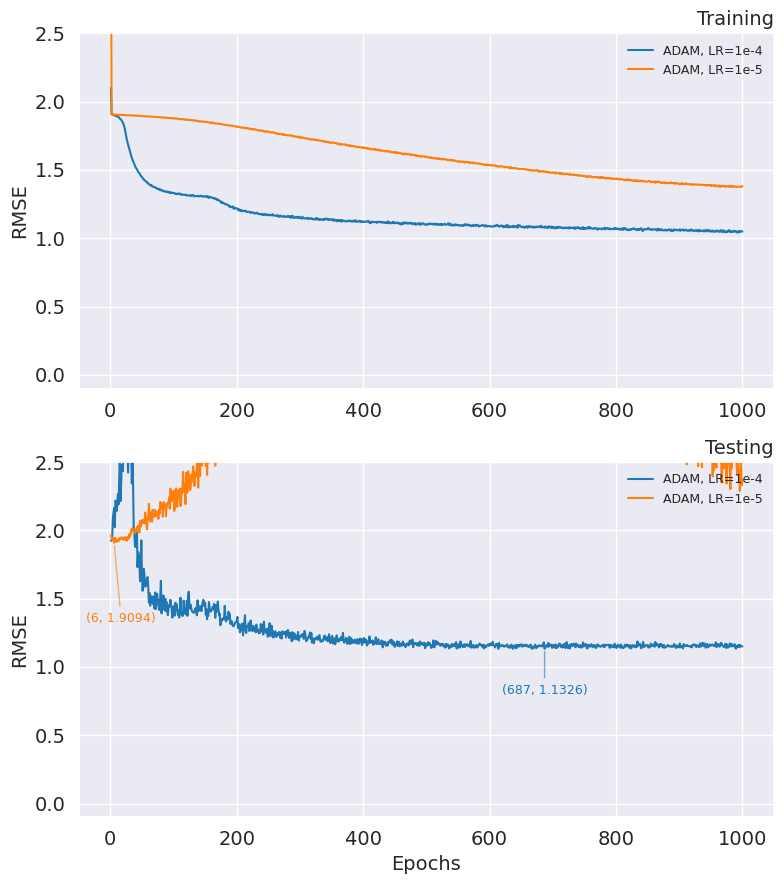

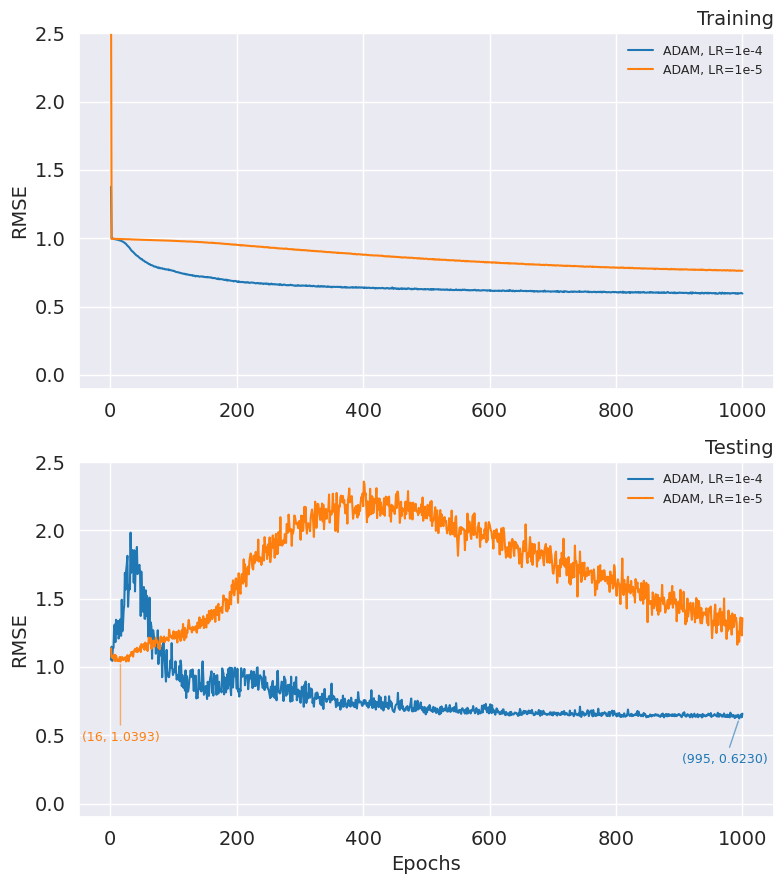

In [17]:
b_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn-DMS_OLD-binding-2024-12-05_17-52/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/adam.lr1e-05.bert_gcn-DMS_OLD-binding-2024-12-05_17-49/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_gcn.binding"
b_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (5,-50)
}
print("Binding:")
plot_comparative_lr_blstm_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf", "GCN")

e_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn-DMS_OLD-expression-2024-12-05_17-51/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/adam.lr1e-05.bert_gcn-DMS_OLD-expression-2024-12-05_17-50/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_gcn.expression"
e_coords = {
    "ADAM, LR:1e-4": (-10,-25),
    "ADAM, LR:1e-5": (0,-50)
}
print("\nExpression:")
plot_comparative_lr_blstm_log_file(e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf", "GCN")

--- 
### ESM-FCN

Binding:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 76, rmse 0.5235
ADAM, LR=1e-5: epoch 965, rmse 0.5185

Expression:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 233, rmse 0.3145
ADAM, LR=1e-5: epoch 985, rmse 0.3172


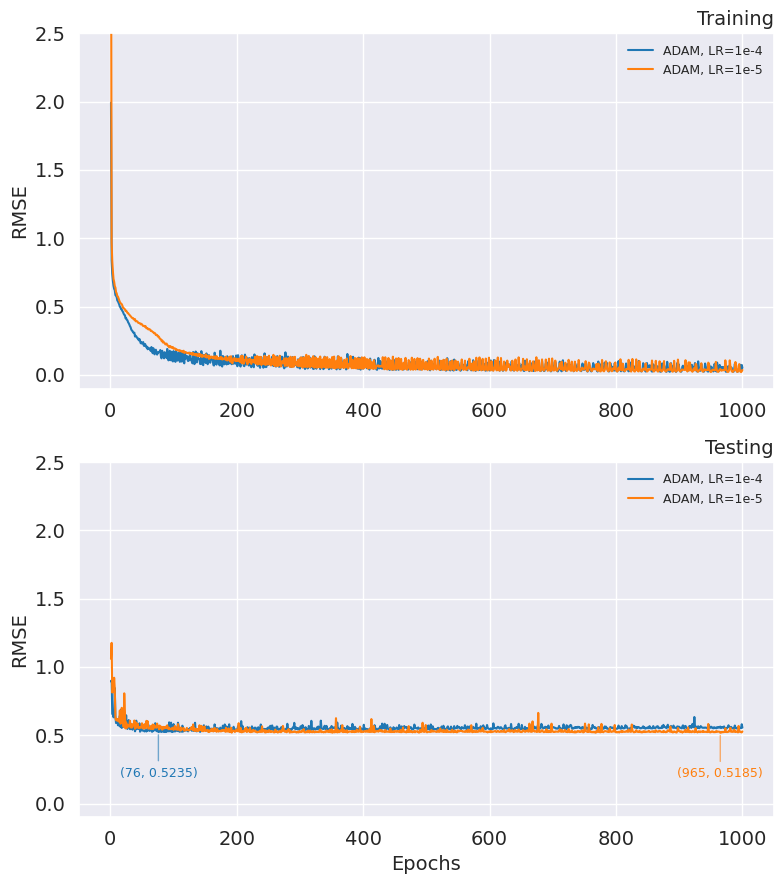

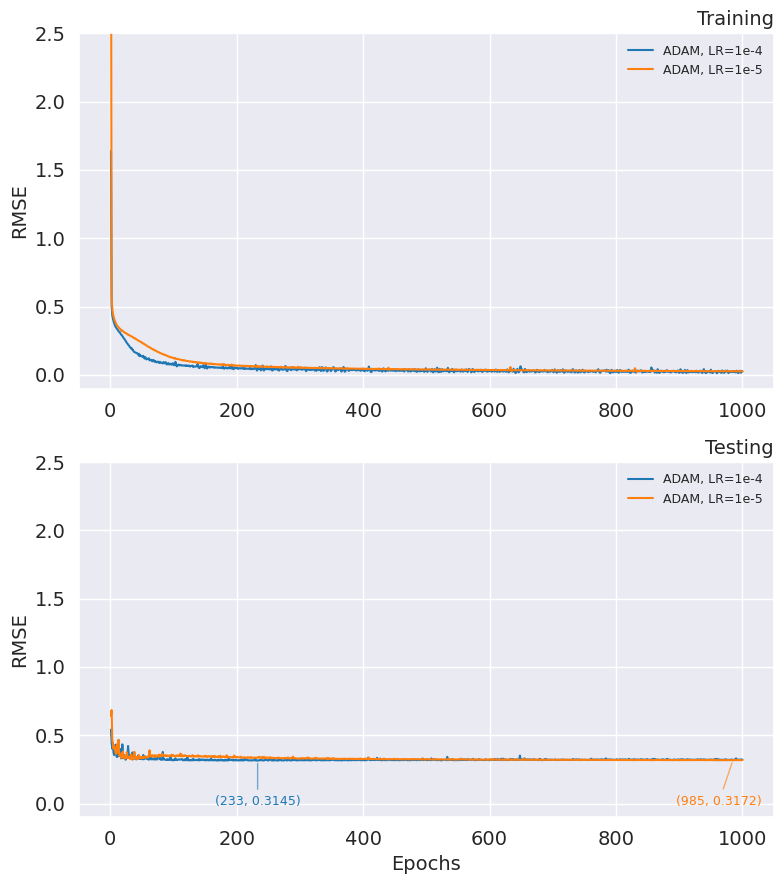

In [9]:
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-binding-2024-12-05_04-12/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_fcn.binding"
b_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-expression-2024-12-04_17-56/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_fcn.expression"
e_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (-10,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### ESM-GCN

Binding:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 109, rmse 0.5570
ADAM, LR=1e-5: epoch 576, rmse 0.5347

Expression:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 189, rmse 0.3323
ADAM, LR=1e-5: epoch 974, rmse 0.3213


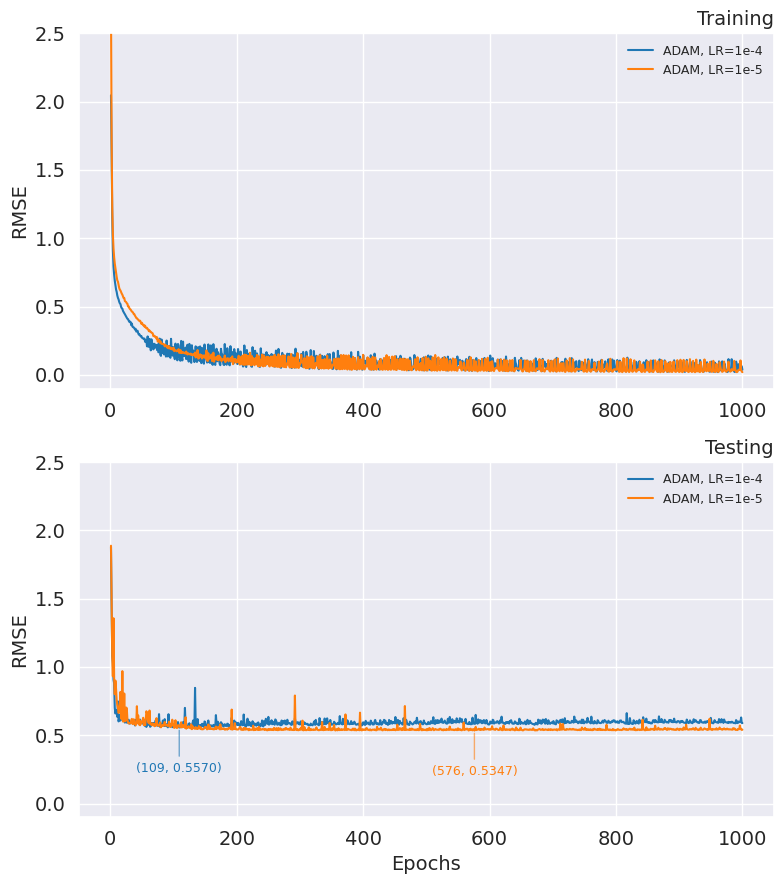

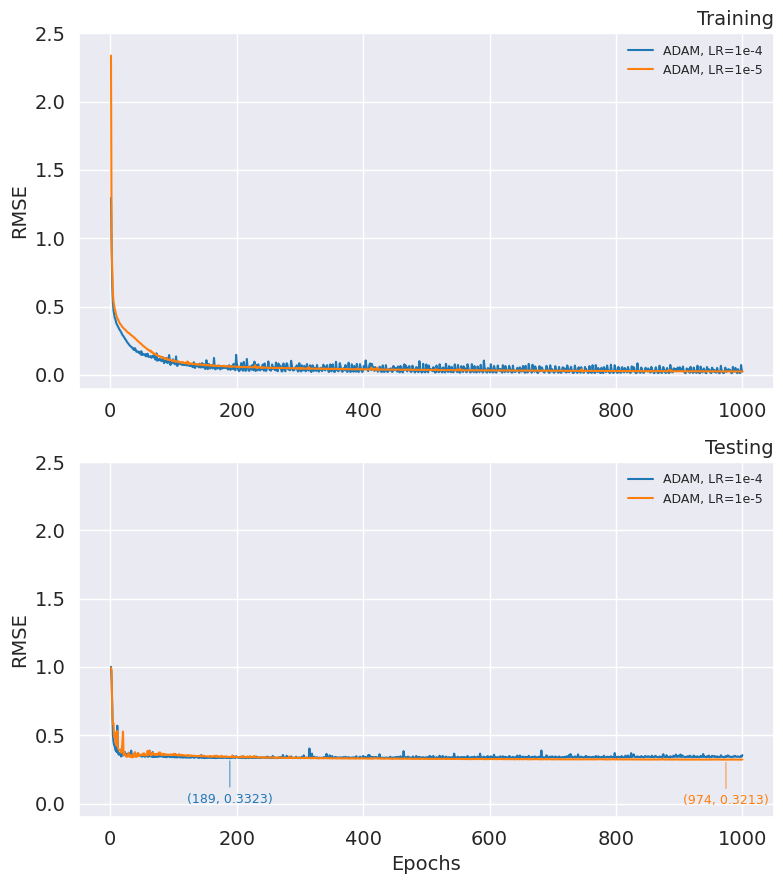

In [10]:
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-04.esm_gcn-DMS_OLD-binding-2024-12-09_00-32/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-binding-2024-12-07_09-12/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-04.esm_gcn-DMS_OLD-expression-2024-12-09_00-31/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-expression-2024-12-07_09-13/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_gcn.expression"
e_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

--- 
### ESM-BLSTM

Binding:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 99, rmse 0.5362
ADAM, LR=1e-5: epoch 329, rmse 0.5242

Expression:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 233, rmse 0.3227
ADAM, LR=1e-5: epoch 907, rmse 0.3202


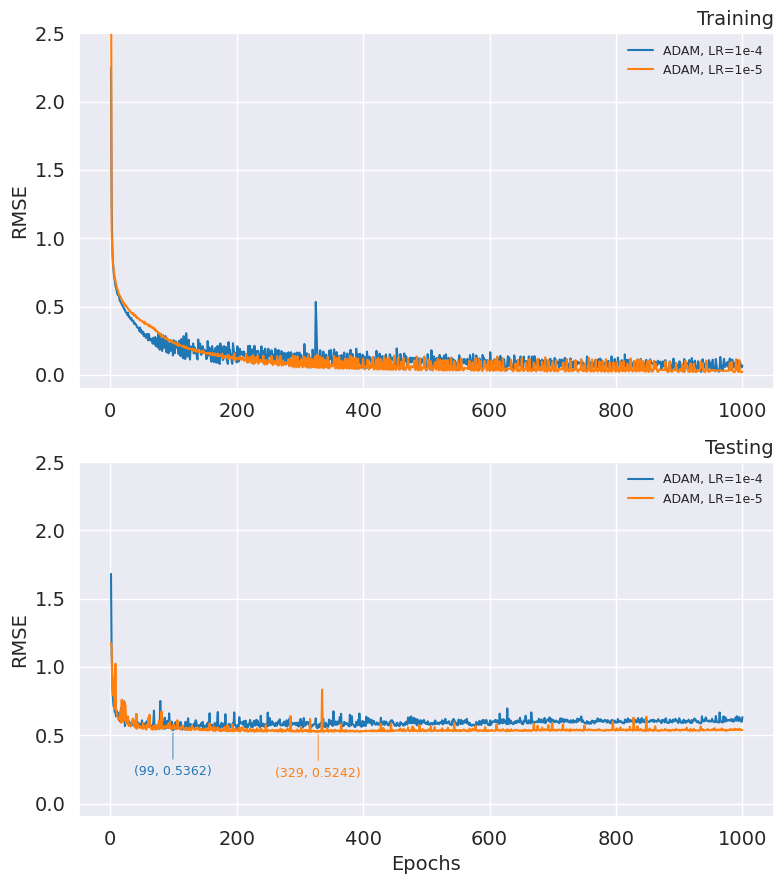

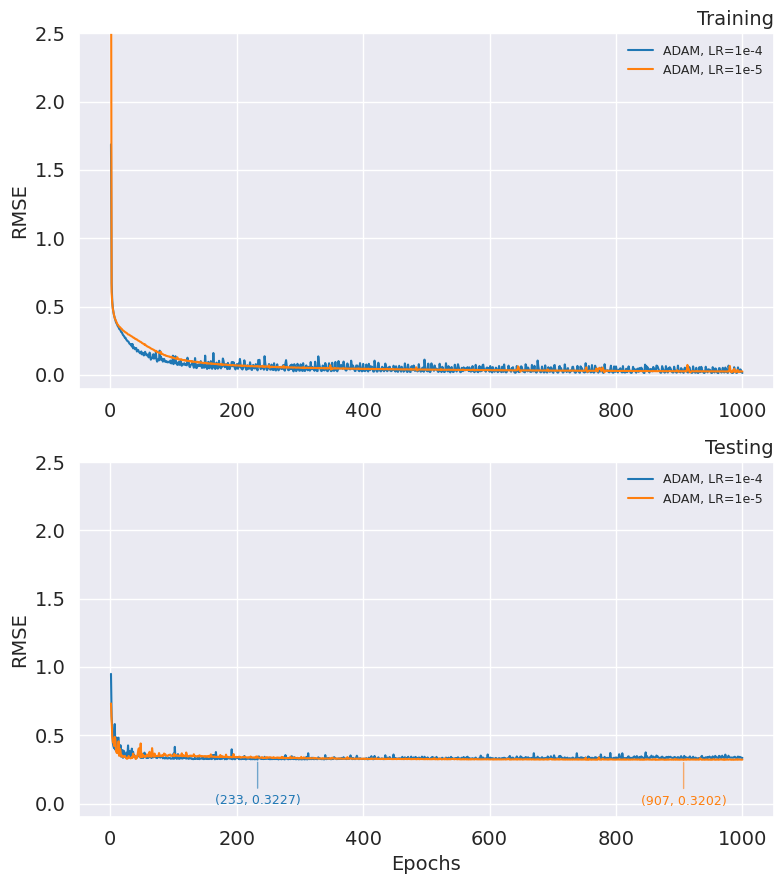

In [11]:
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm/adam.lr1e-04.esm_blstm-DMS_OLD-binding-2024-12-17_10-42/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm/adam.lr1e-05.esm_blstm-DMS_OLD-binding-2024-12-07_08-58/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm.binding"
b_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm/adam.lr1e-04.esm_blstm-DMS_OLD-expression-2024-12-17_10-43/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm/adam.lr1e-05.esm_blstm-DMS_OLD-expression-2024-12-07_09-00/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm.expression"
e_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### ESM-BLSTM Initialized w/ BERT_MLM_ESM_INIT

Binding:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 119, rmse 0.5954
ADAM, LR=1e-5: epoch 447, rmse 0.6573

Expression:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 211, rmse 0.3383
ADAM, LR=1e-5: epoch 952, rmse 0.3486


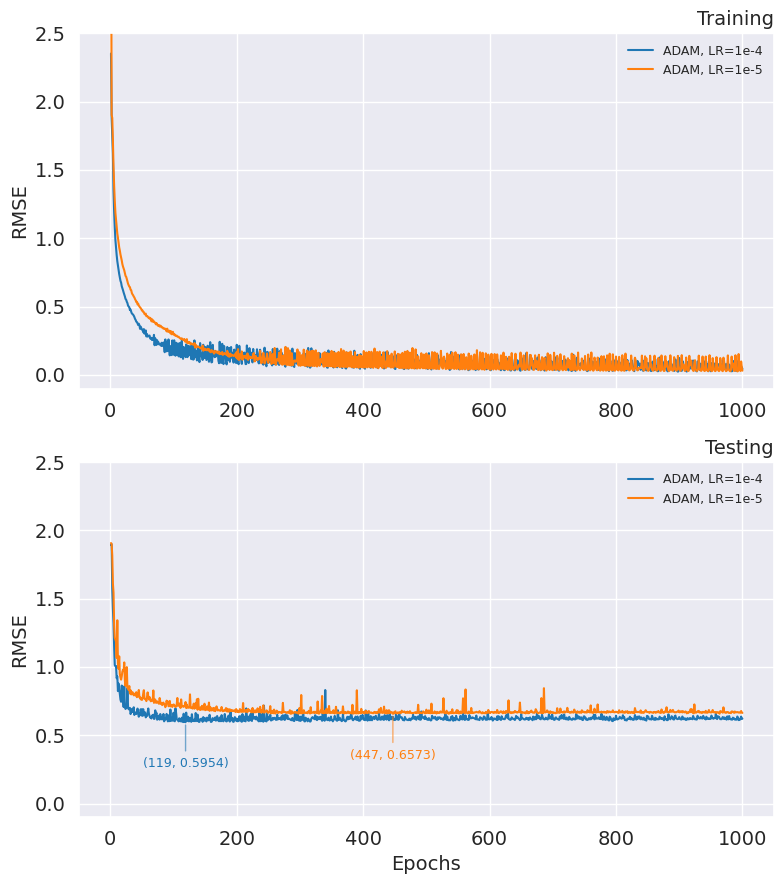

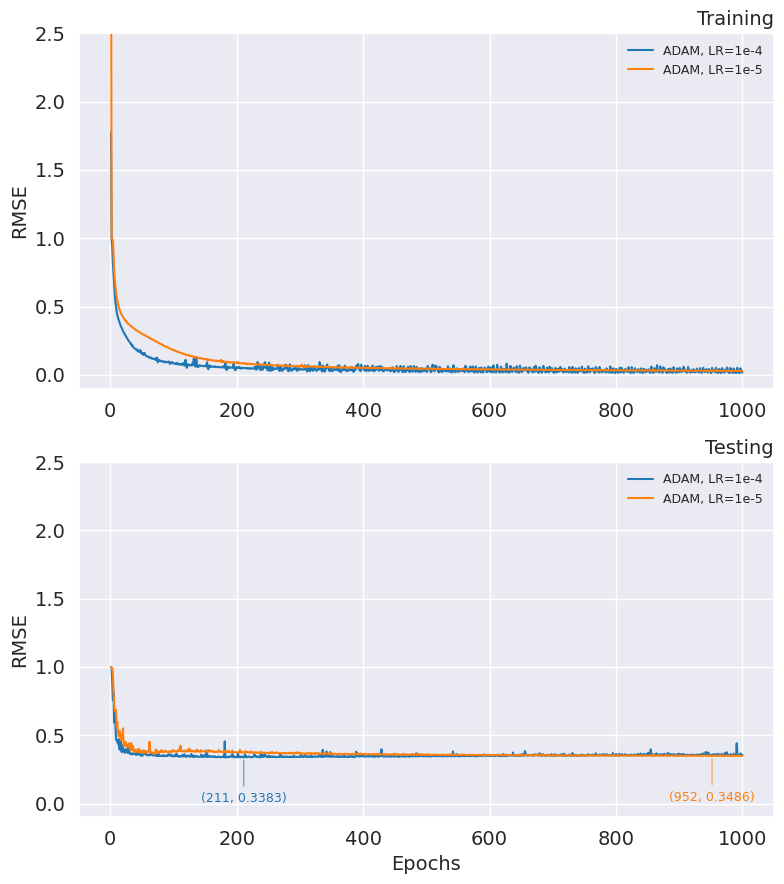

In [3]:
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-04.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-12-07_09-28/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-05.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-12-07_09-02/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm-bert_mlm_esm_init.binding"
b_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-04.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-12-07_09-36/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-05.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-12-07_09-18/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm-bert_mlm_esm_init.expression"
e_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### FCN ESM-CLS Preembedded

Binding:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 271, rmse 1.2743
ADAM, LR=1e-5: epoch 987, rmse 1.2238

Expression:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 397, rmse 0.6534
ADAM, LR=1e-5: epoch 1000, rmse 0.6107


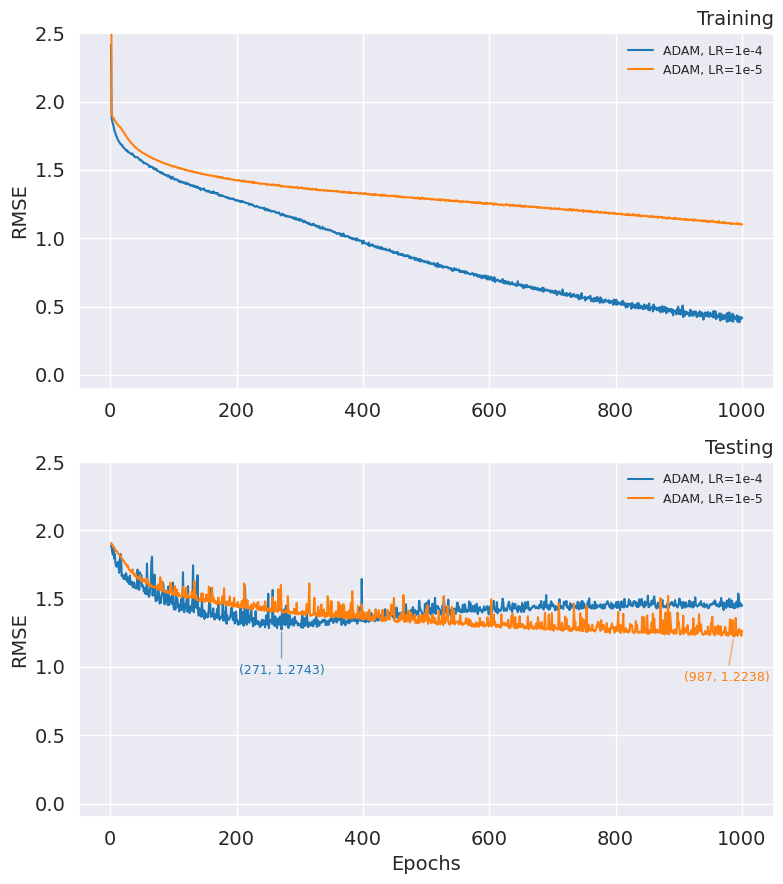

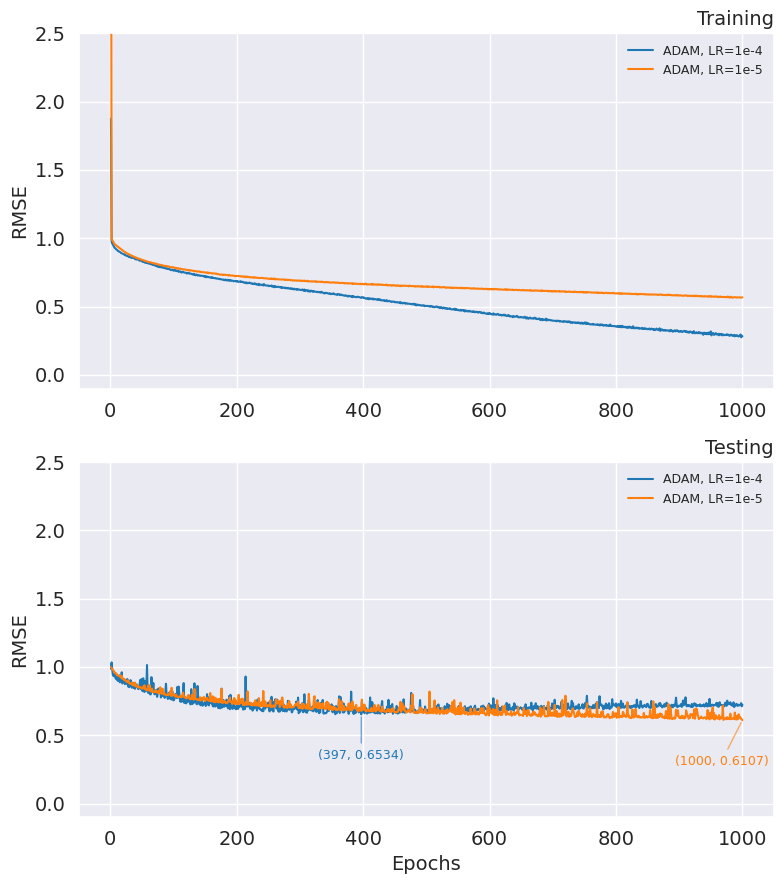

In [25]:
b_adam_lr_1e_neg_4 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-04.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-12-04_16-15/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-05.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-12-04_18-51/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/fcn-esm_cls_preembedded.binding"
b_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (-5,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_adam_lr_1e_neg_4 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-04.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-12-04_17-26/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-05.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-12-04_17-28/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/fcn-esm_cls_preembedded.expression"
e_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (-15,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### BLSTM ESM-AA Preembedded

Binding:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 547, rmse 0.5518
ADAM, LR=1e-5: epoch 971, rmse 0.5891

Expression:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 193, rmse 0.3335
ADAM, LR=1e-5: epoch 946, rmse 0.3555


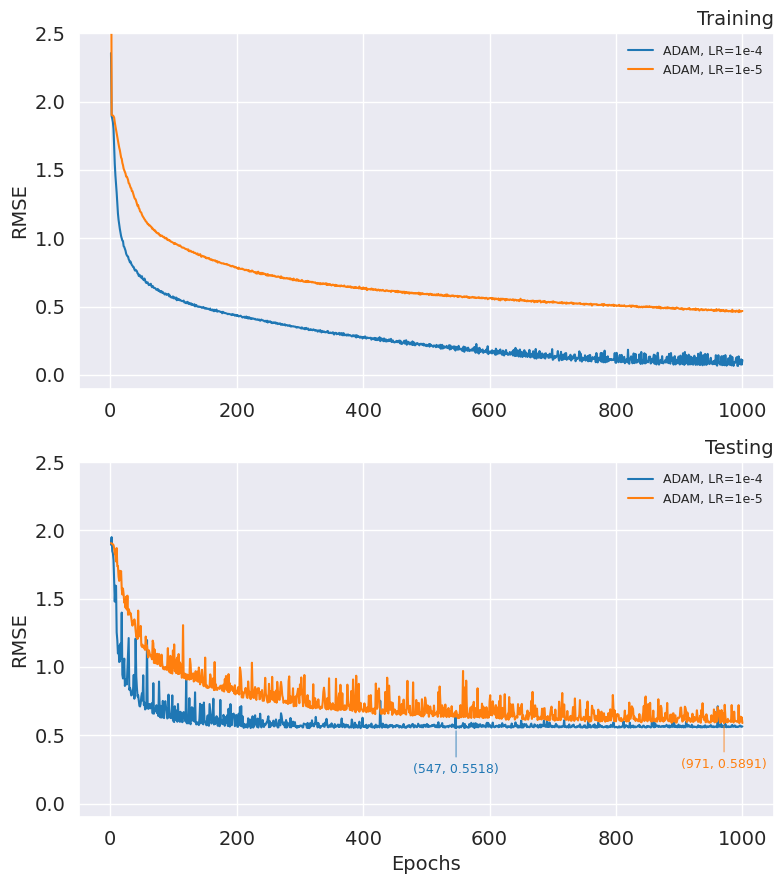

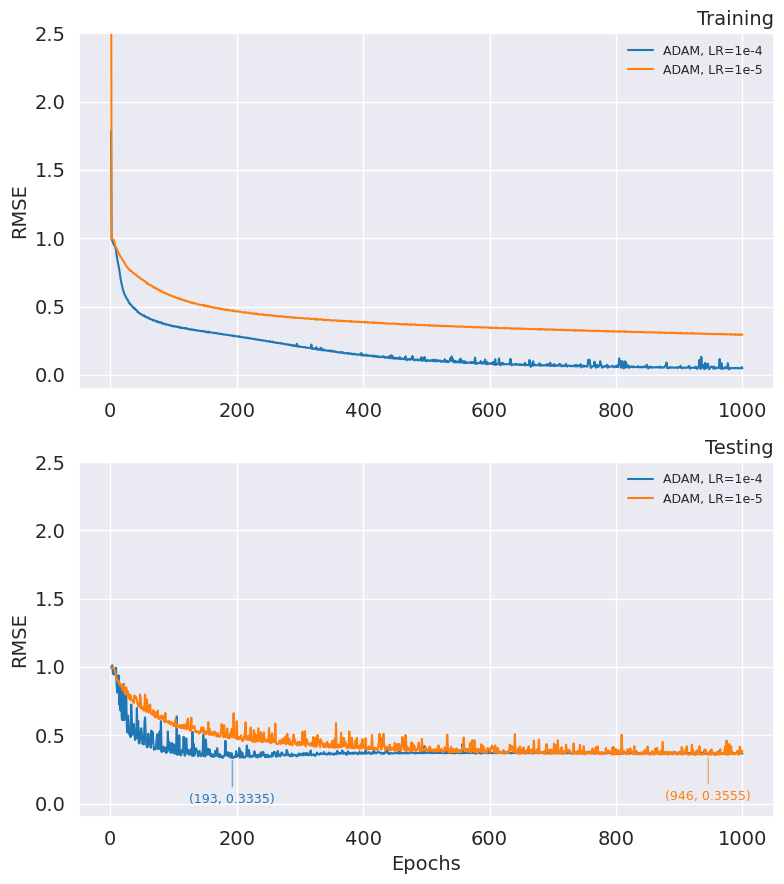

In [27]:
b_adam_lr_1e_neg_4 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-04.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-12-05_01-05/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-05.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-12-04_14-58/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm-esm_aa_preembedded.binding"
b_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_adam_lr_1e_neg_4 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-04.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-12-05_01-06/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-05.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-12-04_15-00/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm-esm_aa_preembedded.expression"
e_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (0,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### BLSTM NLP Preembedded w/ Finetuned BERT_MLM_ESM_INIT

Binding:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 946, rmse 1.9049
ADAM, LR=1e-5: epoch 999, rmse 1.1148

Expression:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 676, rmse 0.9963
ADAM, LR=1e-5: epoch 986, rmse 0.5834


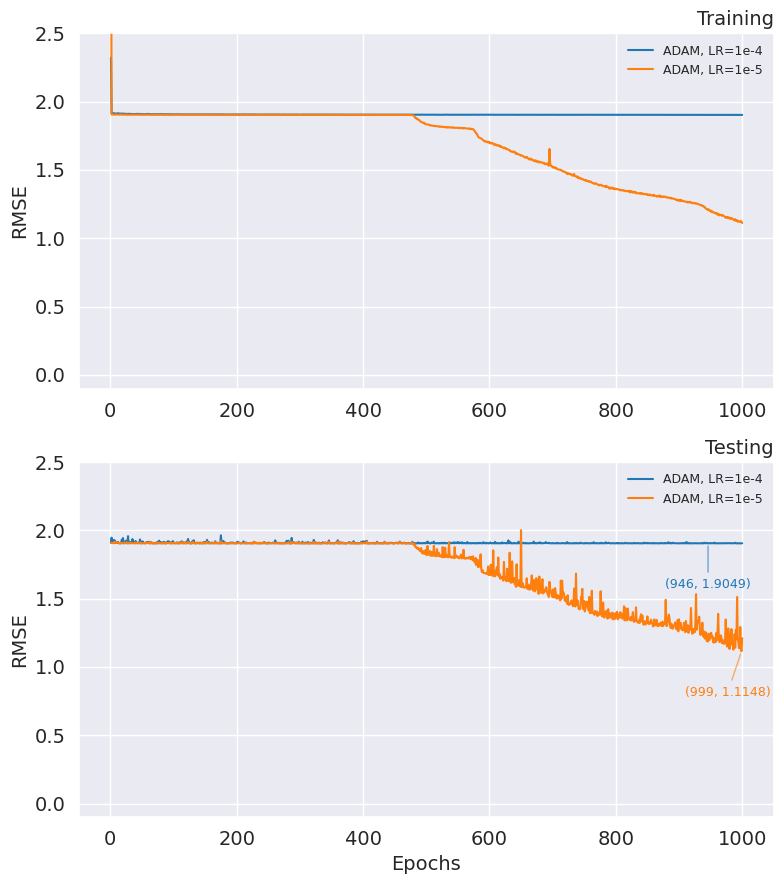

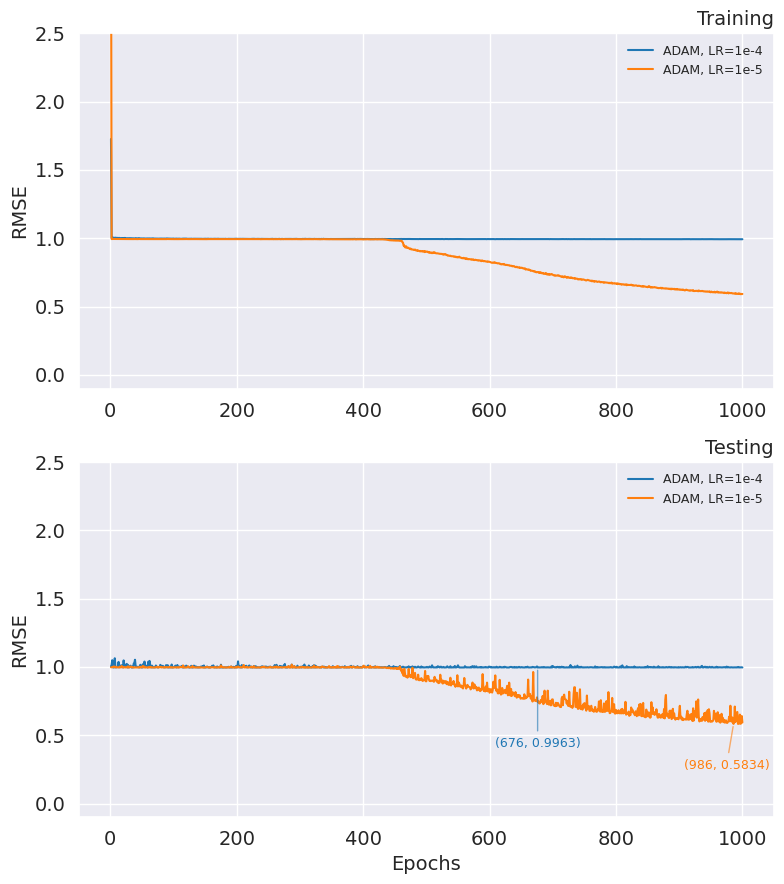

In [30]:
b_adam_lr_1e_neg_4 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-04.blstm-NLP_preembedded-DMS_OLD-binding-2024-12-05_11-05/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-05.blstm-NLP_preembedded-DMS_OLD-binding-2024-12-05_04-05/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm-nlp_preembedded.binding"
b_coords = {
    "ADAM, LR:1e-4": (0,-25),
    "ADAM, LR:1e-5": (-10,-25)
}
print("Binding:")
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_adam_lr_1e_neg_4 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-04.blstm-NLP_preembedded-DMS_OLD-expression-2024-12-05_11-04/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-05.blstm-NLP_preembedded-DMS_OLD-expression-2024-12-05_04-06/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm-nlp_preembedded.expression"
e_coords = {
    "ADAM, LR:1e-4": (0,-50),
    "ADAM, LR:1e-5": (-5,-25)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### GCN ESM-AA Preembedded

Binding:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 997, rmse 1.0719
ADAM, LR=1e-5: epoch 1000, rmse 1.2945

Expression:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 993, rmse 0.5409
ADAM, LR=1e-5: epoch 997, rmse 0.6805


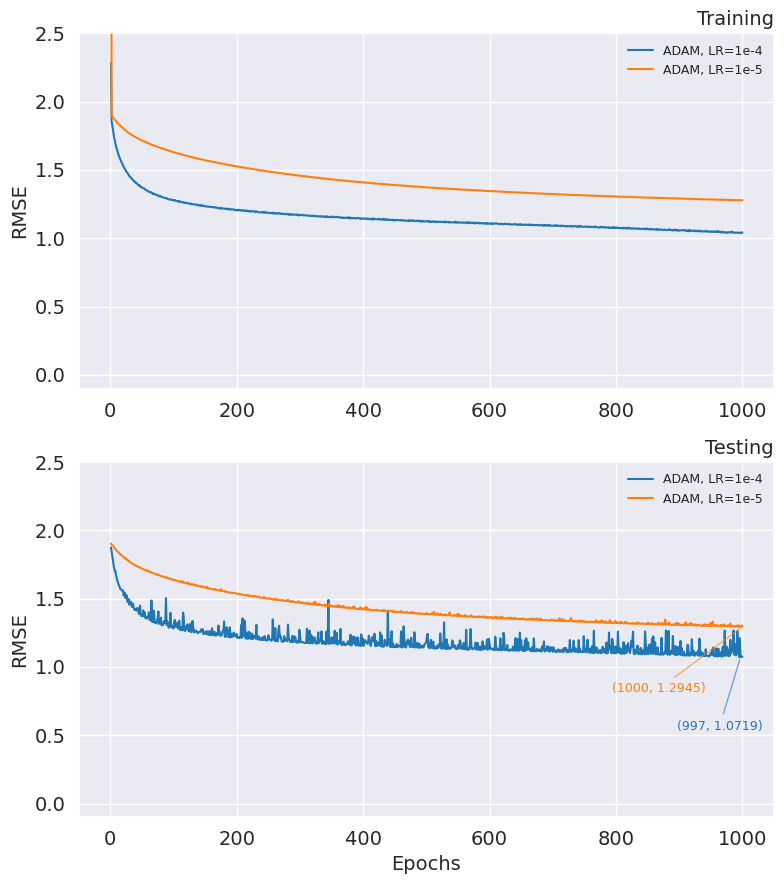

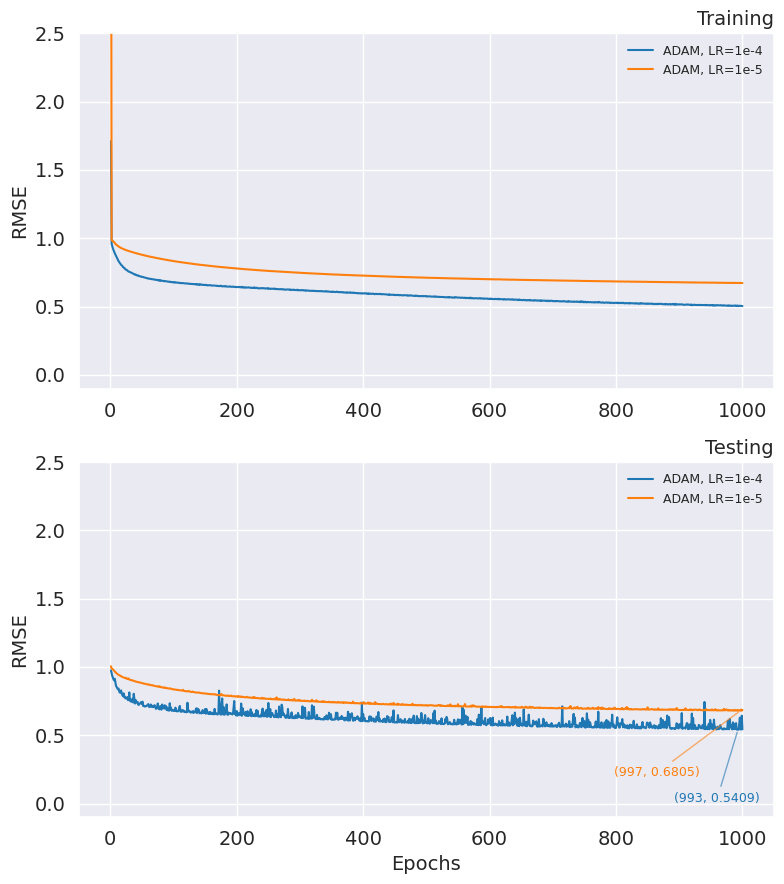

In [31]:
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-12-05_01-01/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-05.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-12-04_14-49/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-esm_aa_preembedded.binding"
b_coords = {
    "ADAM, LR:1e-4": (-15,-45),
    "ADAM, LR:1e-5": (-60,-40)
}
print("Binding:")
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-12-05_00-48/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-05.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-12-04_14-55/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-esm_aa_preembedded.expression"
e_coords = {
    "ADAM, LR:1e-4": (-15,-45),
    "ADAM, LR:1e-5": (-60,-40)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")

---
### GCN NLP Preembedded w/ Finetuned BERT_MLM_ESM_INIT

Binding:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 989, rmse 1.2092
ADAM, LR=1e-5: epoch 998, rmse 1.3947

Expression:
Best test RMSE at epoch x:
ADAM, LR=1e-4: epoch 999, rmse 0.6670
ADAM, LR=1e-5: epoch 1000, rmse 0.7479


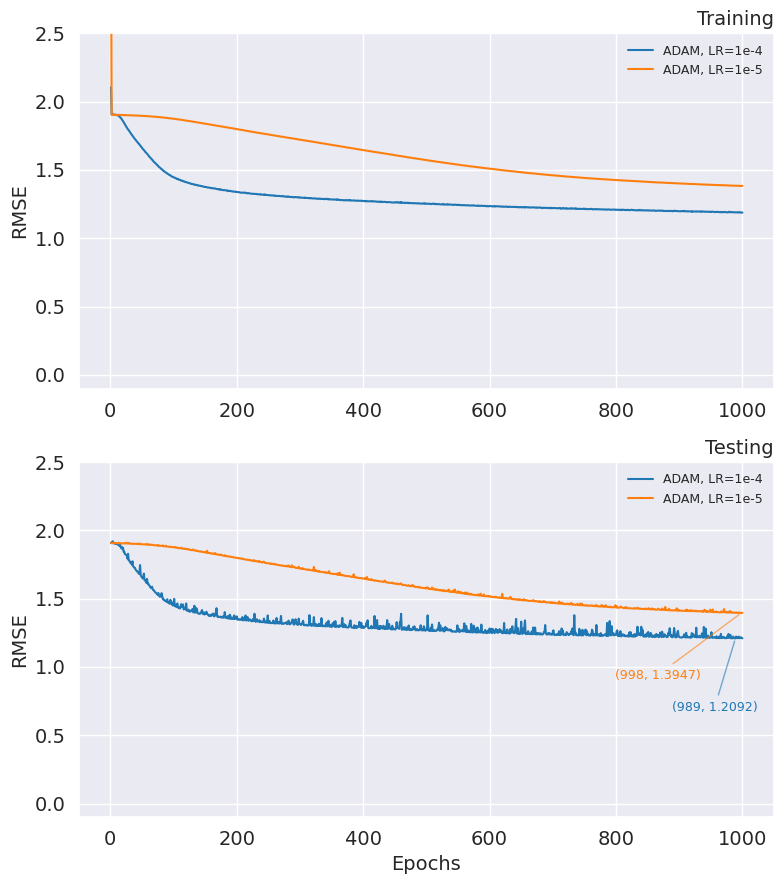

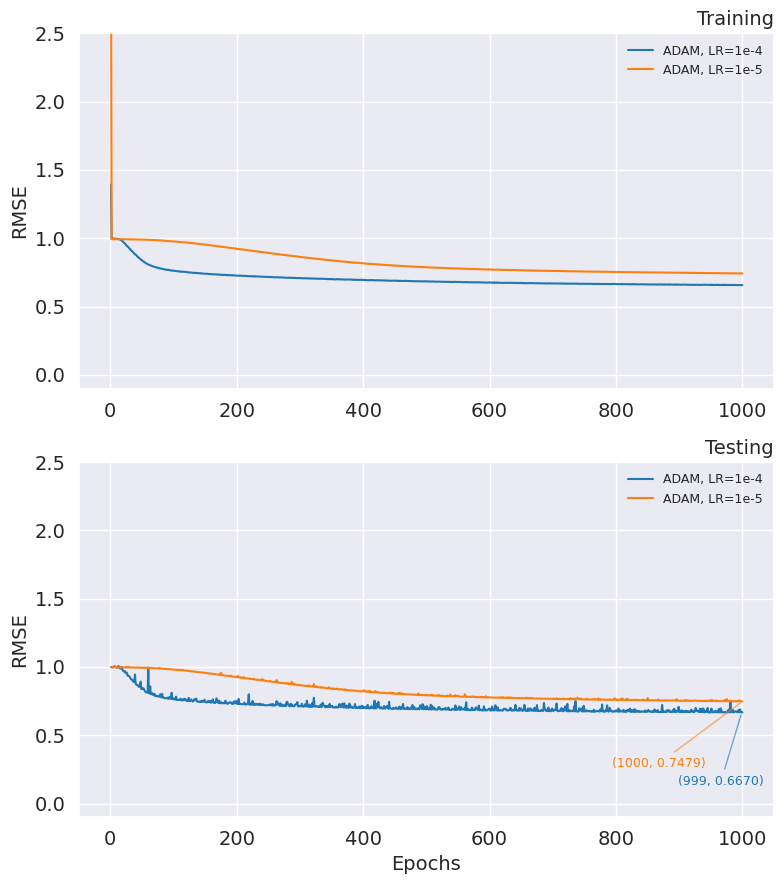

In [32]:
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-binding-2024-12-05_09-14/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-05.gcn-NLP_preembedded-DMS_OLD-binding-2024-12-05_09-11/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-nlp_preembedded.binding"
b_coords = {
    "ADAM, LR:1e-4": (-15,-45),
    "ADAM, LR:1e-5": (-60,-40)
}
print("Binding:")
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, b_coords, f"{comparison_file}.model_comp.pdf")

e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-expression-2024-12-05_09-13/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-05.gcn-NLP_preembedded-DMS_OLD-expression-2024-12-05_09-12/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-nlp_preembedded.expression"
e_coords = {
    "ADAM, LR:1e-4": (-15,-45),
    "ADAM, LR:1e-5": (-60,-40)
}
print("\nExpression:")
plot_comparative_lr_log_file(e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, e_coords, f"{comparison_file}.model_comp.pdf")